In [1]:
import anndata as ad
import scanpy as sc
from __future__ import annotations
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, csc_matrix
import pooch
import warnings

print(ad.__version__)

0.12.16


C:\Users\ojwin\AppData\Local\Temp\ipykernel_12504\3135589576.py:10: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print(ad.__version__)


Anndata is used instead of pandas as it allows for the main, large matrix of gene values to be
stored alongside the additional information (extra cell info stored in obs) (extra gene info 
stored in var). It is also processed much faster than pandas as the main matrix is stored in a 
numpy array

Many cell types don't express many genes, this means that in a regular numpy array there would be many zero values. Scanpy.sparse allows for a sparse matrix to be created where these zero values are not stored allowing massive reductions of memory required to store this data

Pooch is a library used to download and cache data for the user straight from its source, instead of making the user download the data set themselves, I won't use it in this first programme though

In [2]:
adata = sc.read_h5ad("dataset.h5ad")

print(adata.shape)


(1087, 15099)


This loads the downloaded dataset, with bigger anndata sets we would probably use pooch to cache it directly from a source
The adata.X (the main shape) is 1087 cells with 15099 genes#

Below we will start to anaylyse the obs (metadata for the types of cells)

In [3]:
print(adata.obs.head())
print("")
print(adata.obs.columns)

                    n_counts  size_factors
Cells                                     
AAACCCAAGGAGAGTA-1    7393.0        7393.0
AAACGCTTCAGCCCAG-1    5069.0        5069.0
AAAGAACAGACGACTG-1    4015.0        4015.0
AAAGAACCAATGGCAG-1    2589.0        2589.0
AAAGAACGTCTGCAAT-1    6152.0        6152.0

Index(['n_counts', 'size_factors'], dtype='object')


N_counts is a measurement for the total RNA collected from a cell (basically all the gene counts added together). Cells with very low n count may be dead and cells with double may be 2 cells colelcted at once. Allows for quality control

Size_factors allows for accurate normalisation of cells. As some cells may be sequenced more deeply and thus have higher n_count, the size_factor says how much to normalise it by.


Below we will start to analyse the vars (gene metadata)

In [4]:
print(adata.var.head())
print("")
print(adata.var.columns)

          n_cells feature_name    hvg  hvg_score
Genes                                           
A1BG          213         A1BG  False  -0.540297
A1BG-AS1       33     A1BG-AS1  False  -0.137727
A2M             8          A2M  False   0.680062
A2M-AS1       121      A2M-AS1   True   7.132755
A4GALT          3       A4GALT  False   0.212352

Index(['n_cells', 'feature_name', 'hvg', 'hvg_score'], dtype='object')


n_cells: Number of cells in which that gene is detected
feature_name: the human name for the gene
hvg: highly variable gene (would be true for a gene that varies a lot in a cell)
Hence hvg score: decides how variable a gene is

We need to check if our data has already been normalised so we will run the code below

print(adata.X[:5, :5])
print(adata.X.min())
print(adata.X.max())

This is an error as adata.X is stored in layers (Counts and Normalised) (This is shown in the code below)
We will be using normalised for sake of learning for now

In [5]:
print(adata)
print(adata.layers.keys())

AnnData object with n_obs × n_vars = 1087 × 15099
    obs: 'n_counts', 'size_factors'
    var: 'n_cells', 'feature_name', 'hvg', 'hvg_score'
    uns: '_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'knn', 'normalization_id', 'pca_variance', 'var_names_all'
    obsm: 'X_pca'
    varm: 'pca_loadings'
    layers: 'counts', 'normalized'
    obsp: 'knn_connectivities', 'knn_distances'
KeysView(Layers with keys: counts, normalized)


Let's explain what is seen below, we will assign the normalised main matrix to adata.X

Then we view the first 5 cells/genes of the main matrix.  This only shows 1 value as all the other values are 0, this is normal as single cell gene expression data is very sparse.
This is what it would look like in a regular dataset, but ofc we need to save storage space so it only stores non-zero values
0   0   0   0     0
0   0   0   0     0
0   0   0   0     0
0   0   0   1.58  0
0   0   0   0     0

We then find the min and max, min obviously being 0 and max being 8. As the max is between 5-10 it shows the data has already been log-normalised (good, we are using the normalised layer).
Log-normalisation is basically just a process of regular normalisation (say setting all gene expression values to 10,000) and then taking a log as these numbers are too big to work with

In [6]:
adata.X = adata.layers["normalized"].copy()
print(adata.X[:5, :5])
print(adata.X.min())
print(adata.X.max())

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 1 stored elements and shape (5, 5)>
  Coords	Values
  (3, 3)	1.5815517902374268
0.0
8.413944


Let's do some quality control, the control graphs plotted below show the distribution of how many genes were detected in each cell (left), and the graph on the right shows the total counts of each cell highlighting how high quality the cell has been sequenced

The first line of kernel of code is to use scanpy library to preprocess the data and to calculate Quality Control information 



In [7]:
sc.pp.calculate_qc_metrics(
    adata,
    layer="counts",
    inplace=True,
    percent_top=None,
)

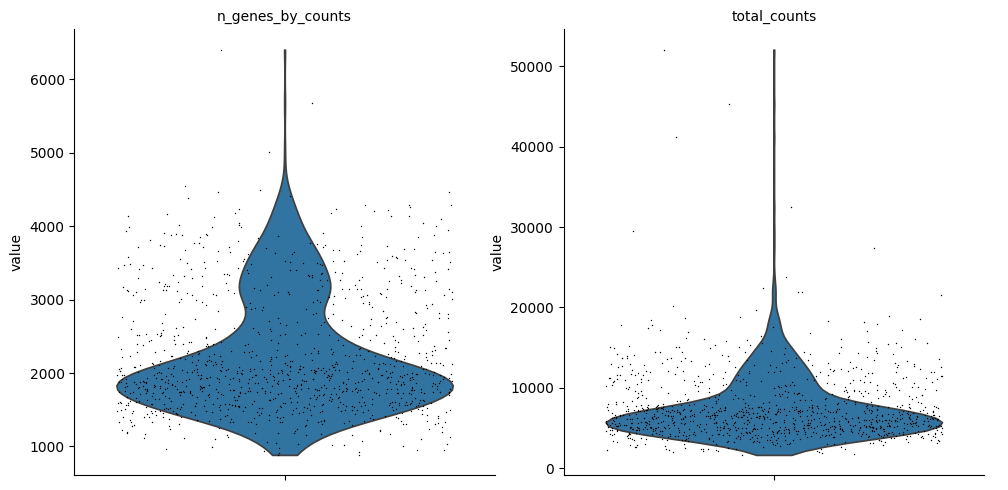

In [8]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True,
)

We now have the data set up in the way we want it, with the main matrix adata.X

We now need to explore highly variable genes to see if we can reduce the dimensionality of the data.
Below shows there are 1000 genes with a significant hvg score to declare the gene highly variable

In [9]:
adata.var["hvg"].value_counts()

hvg
False    14099
True      1000
Name: count, dtype: int64

Let's now subset these highly variable genes  
The colon means we keep all cells (so we are not selecting obs), the second part means we are just selecting genes where hvg == True

In [10]:
adata_hvg = adata[:, adata.var["hvg"]].copy()
adata_hvg.shape

(1087, 1000)

We can now beging PCA in order to reduce the dimensionality to allow for visualisation and clustering
Let's run the built in PCA function from scanpy in order to reduce the dimensionality of our already reduced HVG gene dataset
This turns 1087 cells x 1000 genes into 1087 cells x 50 ish principle components (these principle components are not genes, they are mathmatical axes which capture major patterns in variation between cells)
E.g. PC1 may separate lymphocytes from monocytes, then PC2 might seperate T cells from B cells

Line 2 shows how many PCs we have as it stores the PCA coordinates for each cell
It is stored in obsm (matrix) instead of obs as each PCA has multiple (50) assigned to each cell which forms a matrix as PCA is too large for 1 collumn

In [11]:
sc.tl.pca(adata_hvg)
adata_hvg.obsm["X_pca"].shape

(1087, 50)

In [12]:
adata_hvg

AnnData object with n_obs × n_vars = 1087 × 1000
    obs: 'n_counts', 'size_factors', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts'
    var: 'n_cells', 'feature_name', 'hvg', 'hvg_score', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: '_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'knn', 'normalization_id', 'pca_variance', 'var_names_all', 'pca'
    obsm: 'X_pca'
    varm: 'pca_loadings', 'PCs'
    layers: 'counts', 'normalized'
    obsp: 'knn_connectivities', 'knn_distances'

The graph below shows how much variation each PC shows, helps to decide how many PCs to use later on as some PCs contribute to the overall variation more than others
The y axis is 10^y so shows a log scale with PC1 showing most variation (10%)

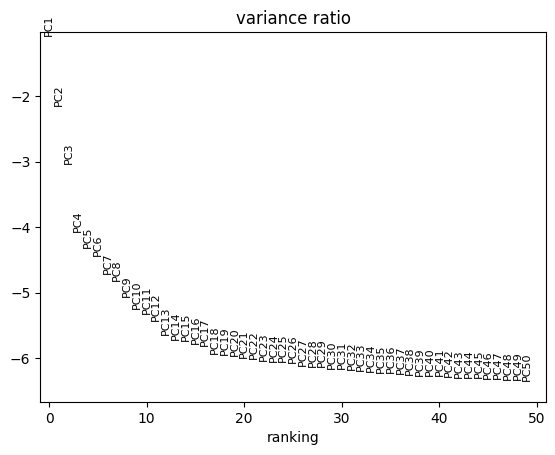

In [13]:
sc.pl.pca_variance_ratio(adata_hvg, n_pcs=50, log=True)

The graphs below show 
Each dot = 1 cell
Then compares PC1 and PC2

The cells cluster into groups, this doesn't directly tell us anything apart from the fact that there are 3-4 distict cell populations (e.g. b or t cells) in our data, these will become more clear later

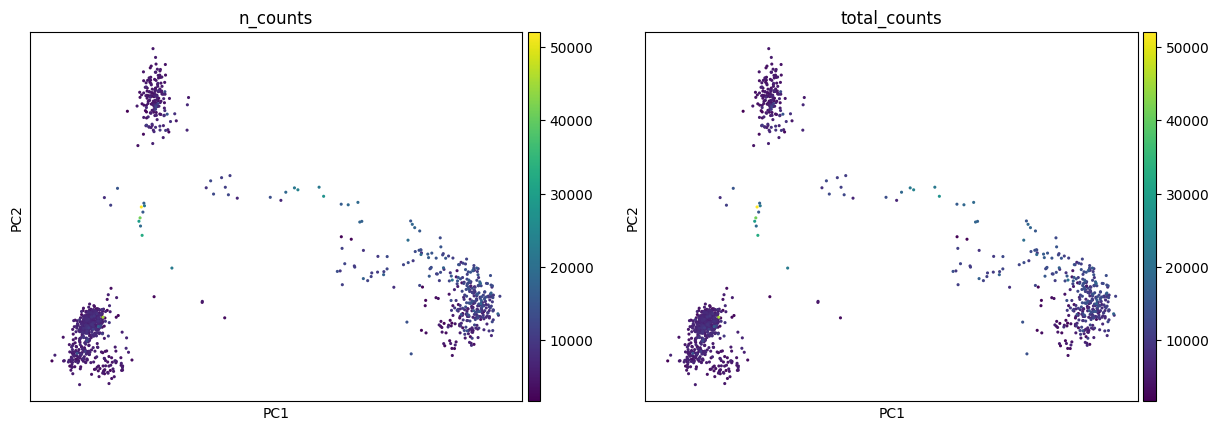

In [14]:
sc.pl.pca(
    adata_hvg,
    color=["n_counts", "total_counts"],
    dimensions=[(0, 1), (0, 1)],
    ncols=2,
    size=20,
)

We have now normalised data, found the highly variable genes and done PCA (as well as some quality control)
We now need to visualise which cells are most similar to each other
It does this by creating a similarity network etc...

Cell A is connected to its 15 most similar cells.
Cell B is connected to its 15 most similar cells.
Cell C is connected to its 15 most similar cells.
(15 n_neghbors are used to match the similarity network above)
Smaller number gives more detail, larger number gives smoother broader structure
UMAP - Uniform Manifold Approximation and Projection

n_pcs means we are only going to use 30 PCs based on our Variation PC graph

The UMAP plot is seen below


In [15]:
sc.pp.neighbors(
    adata_hvg,
    n_neighbors=15,
    n_pcs=30,
)

adata_hvg

AnnData object with n_obs × n_vars = 1087 × 1000
    obs: 'n_counts', 'size_factors', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts'
    var: 'n_cells', 'feature_name', 'hvg', 'hvg_score', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: '_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'knn', 'normalization_id', 'pca_variance', 'var_names_all', 'pca', 'neighbors'
    obsm: 'X_pca'
    varm: 'pca_loadings', 'PCs'
    layers: 'counts', 'normalized'
    obsp: 'knn_connectivities', 'knn_distances', 'distances', 'connectivities'

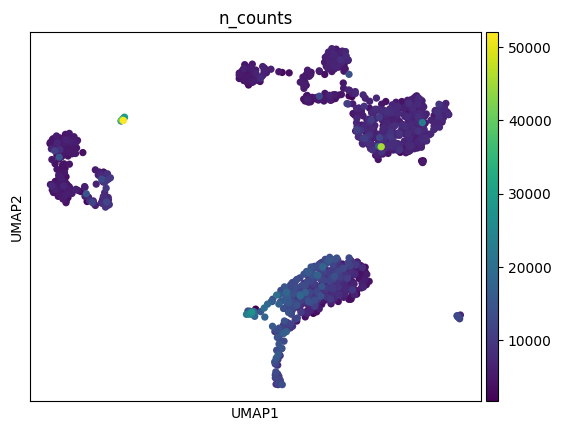

In [16]:
sc.tl.umap(adata_hvg) #calculates umap coords

sc.pl.umap(adata_hvg, color="n_counts") #plots umap coords

The UMAP graph above shows clearly 3 visual structures of data, inidcating there are 3 types of cells with similar gene expression patterns
The green/yellow are cells with higher count so could be outliers, this is quite good interesting for the datapoints just above the leftmost segment that could possibly be an outlier

Now its time to move onto clustering, clustering is the process of now specifically grouping cells into labelled clusters, Leiden clustering is used here. It required the previous completion of neighboring

"In machine learning, clustering groups unlabelled data based on overall similarities, whereas neighboring (like K-Nearest Neighbors) is a method that relies on existing labels to classify new data or make predictions. Think of clustering as sorting a pile of shapes into distinct color groups, while neighboring is asking the closest shapes what category they belong to"

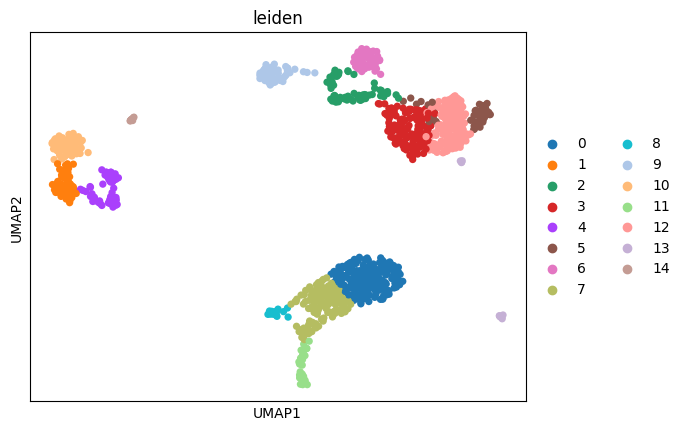

In [17]:
sc.tl.leiden(
    adata_hvg,
    flavor="igraph", #this is the better (faster) version for large datasets
    n_iterations=2 
)

sc.pl.umap(adata_hvg, color=["leiden"])


The output below shows how many cells from the hvgs are in each cluster

In [18]:
adata_hvg.obs["leiden"].value_counts().sort_index()

leiden
0     190
1      55
2      60
3     147
4      57
5      46
6      64
7     124
8      17
9      55
10     65
11     30
12    157
13     12
14      8
Name: count, dtype: int64

Below we have used the same leiden clustering but with a lower resolution 
As we only havw 1087 cells, having 15 clusters is maybe slightly on the large side so we have dropped the resolution to allow for now 10 clusters

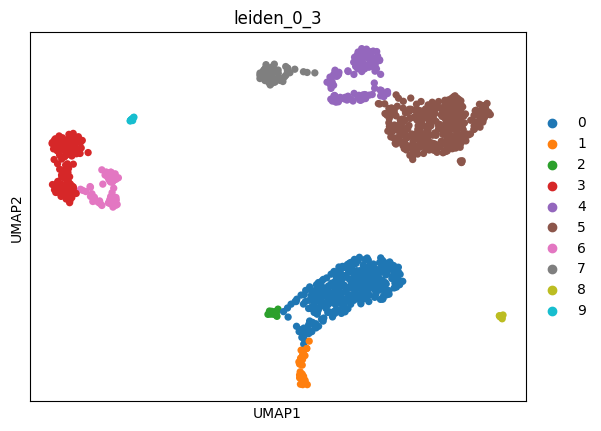

leiden_0_3
0    318
1     29
2     14
3    120
4    122
5    356
6     57
7     55
8      8
9      8
Name: count, dtype: int64

In [19]:
sc.tl.leiden(
    adata_hvg,
    resolution=0.3,
    flavor="igraph",
    n_iterations=2,
    key_added="leiden_0_3",
)

sc.pl.umap(adata_hvg, color="leiden_0_3")

adata_hvg.obs["leiden_0_3"].value_counts().sort_index()

Now we have 10 clusters, we can use marker gene analysis to decipher what cell types these cells are

First of all we need to reassess quality control to see if there are any clusters made up of doublets or error cells, as we can see below, cluster 9 has very high n_counts making it likely to be a doublet. (We could potentially remove it and say it is brough about by errors)

8 has potential to be removed but we will leave it for now

We will also remove 2 as it has high n_counts

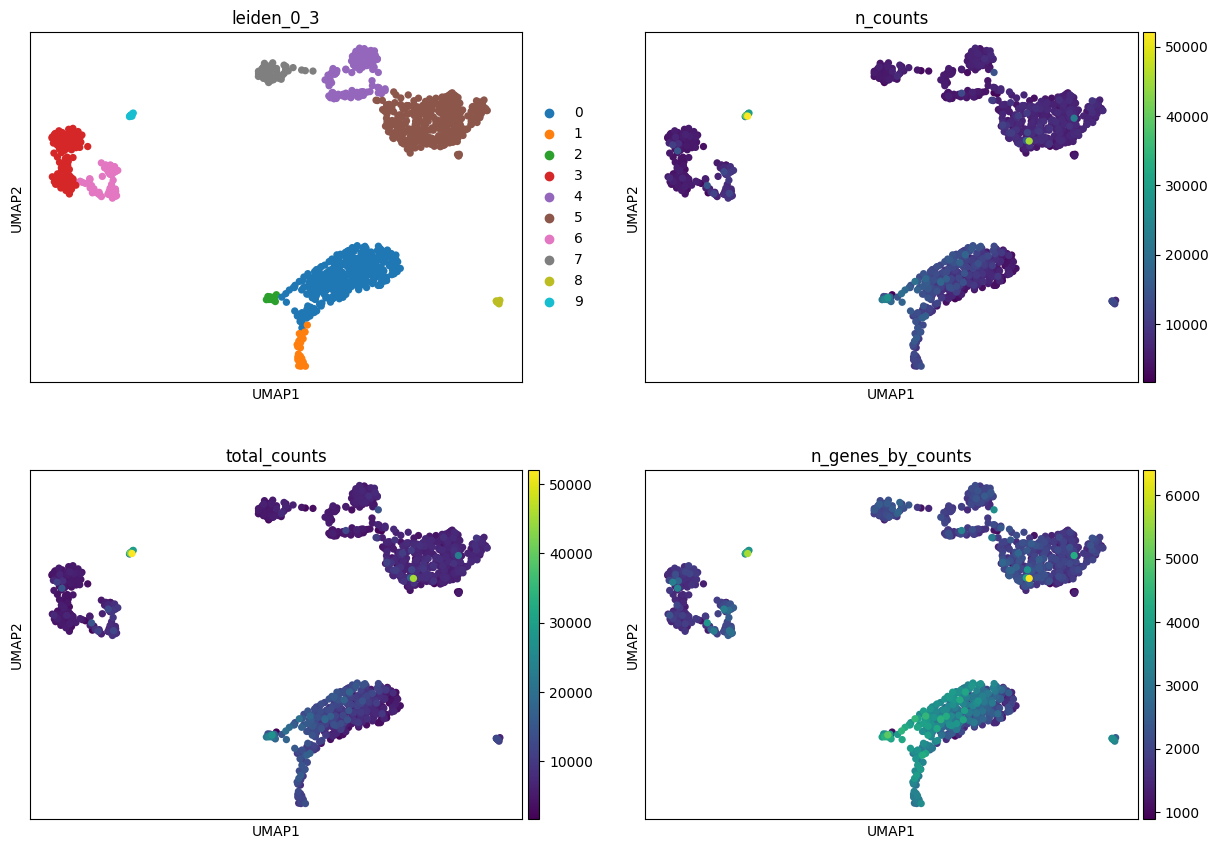

In [20]:
sc.pl.umap(
    adata_hvg,
    color=["leiden_0_3", "n_counts", "total_counts", "n_genes_by_counts"],
    ncols=2,
)

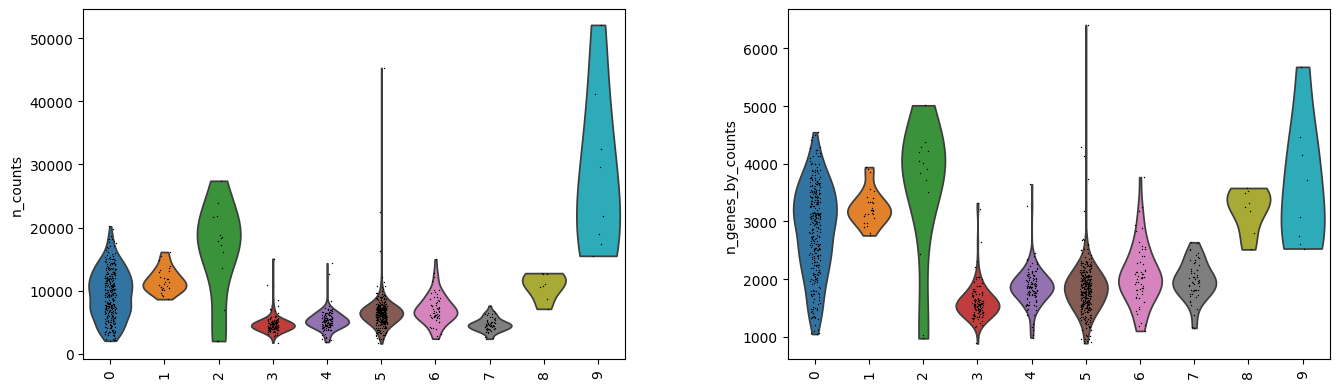

In [21]:
sc.pl.violin(
    adata_hvg,
    keys=["n_counts", "n_genes_by_counts"],
    groupby="leiden_0_3",
    rotation=90,
    multi_panel=True,
)

Let's remove 2 and 9

In [22]:
clusters_to_remove = ["2", "9"]

adata_hvg_filtered = adata_hvg[
    ~adata_hvg.obs["leiden_0_3"].isin(clusters_to_remove)
].copy()

print(adata_hvg.shape)
print(adata_hvg_filtered.shape)

(1087, 1000)
(1065, 1000)


We now need to rerun all the neighbor graph steps now we have removed a couple of clusters

After removing clusters 2 and 9, the dimensionality reduction and clustering steps were rerun. The UMAP layout changed, which is expected because UMAP recalculates a 2D representation from the updated neighbour graph. However, the same broad grouping patterns remain visible, suggesting that the main biological structure of the dataset is preserved after filtering.

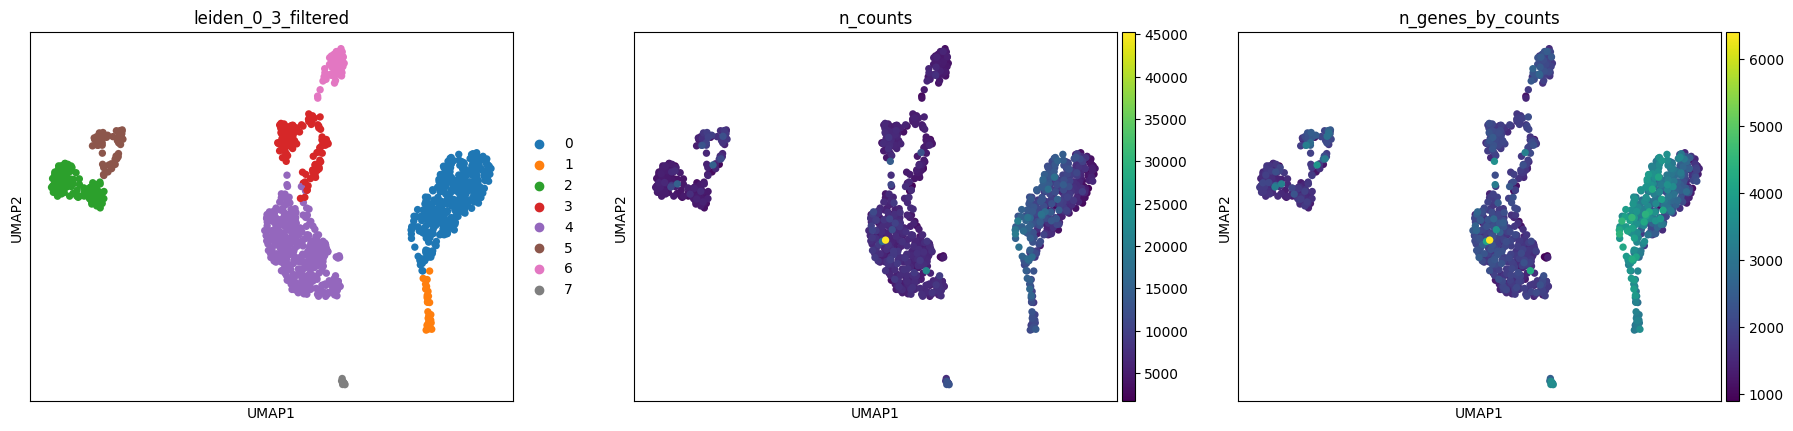

In [23]:
sc.tl.pca(adata_hvg_filtered)

sc.pp.neighbors(
    adata_hvg_filtered,
    n_neighbors=15,
    n_pcs=30,
)

sc.tl.umap(adata_hvg_filtered)

sc.tl.leiden(
    adata_hvg_filtered,
    resolution=0.3,
    flavor="igraph",
    n_iterations=2,
    key_added="leiden_0_3_filtered",
)

sc.pl.umap(
    adata_hvg_filtered,
    color=["leiden_0_3_filtered", "n_counts", "n_genes_by_counts"],
    ncols=3,
)

It's now time to conduct marker gene analyis

We used HVG genes for clustering, but the essential marker genes may not be in the HVG set, so we now must use all of the genes to conduct this

c:\Users\ojwin\AppData\Local\Programs\Python\Python314\Lib\site-packages\scanpy\plotting\_tools\__init__.py:465: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axs[-1].set_ylim(ymin, ymax)


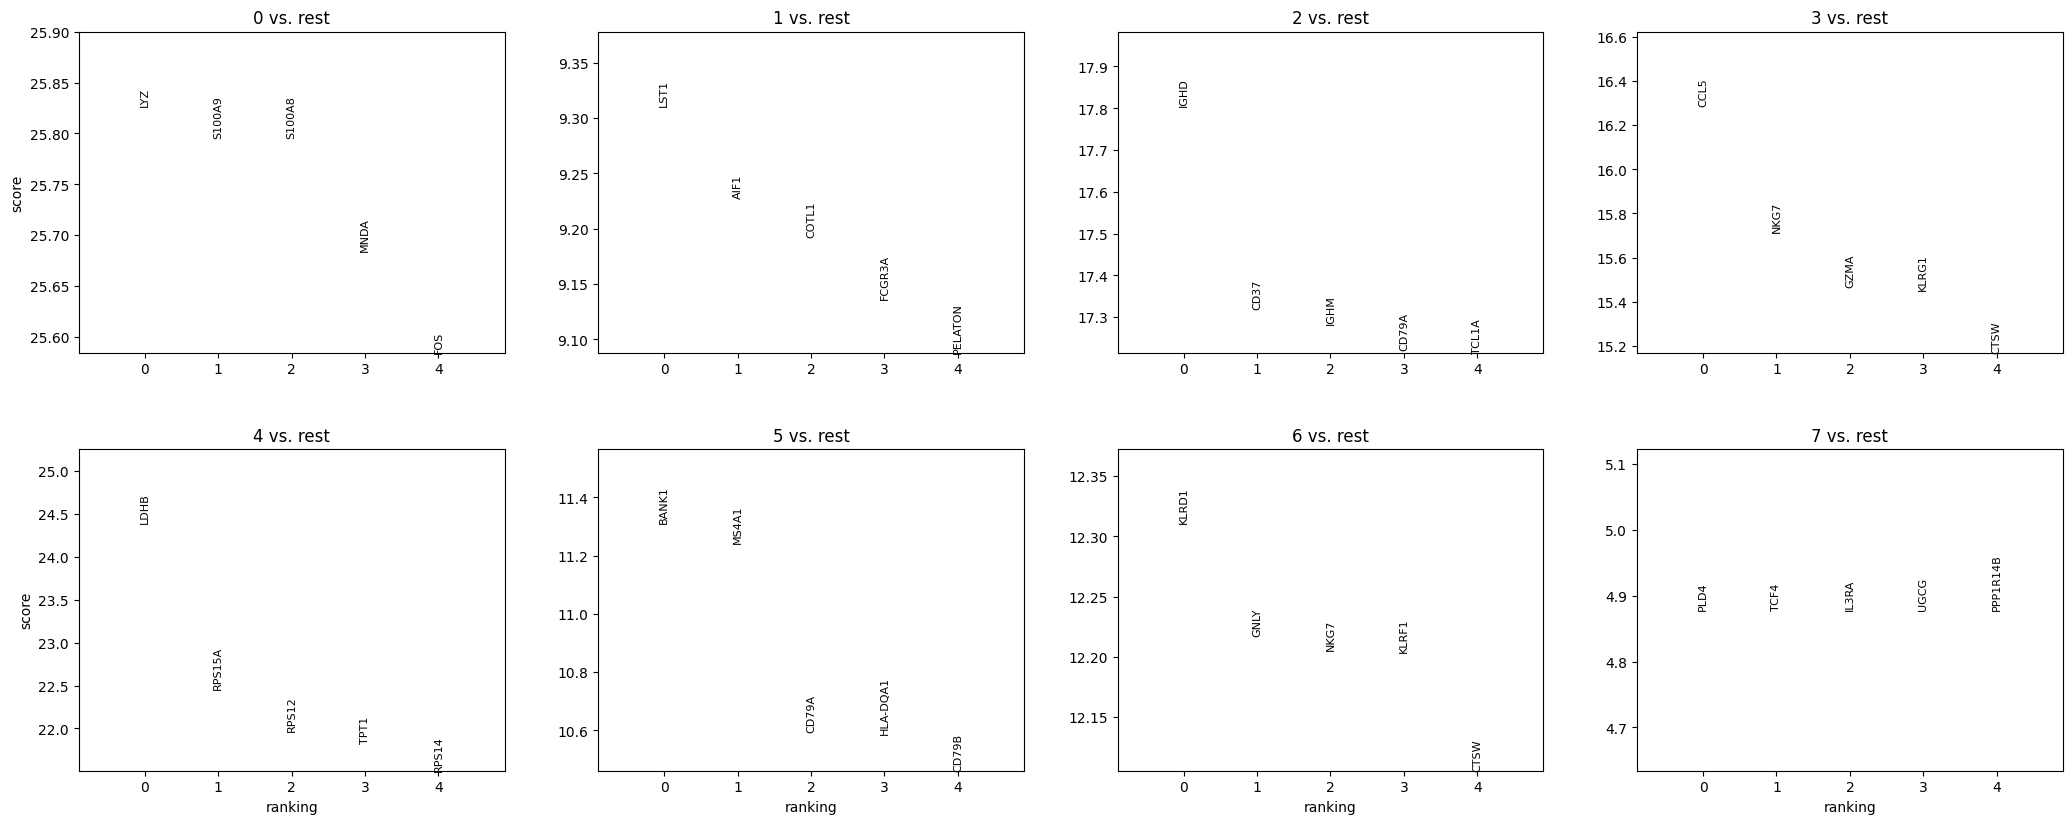

In [24]:
adata.X = adata.layers["normalized"].copy() #we need to use the full dataset rather than our hvg_filtered

adata_marker = adata[adata_hvg_filtered.obs_names, :].copy() #keeps the same filtered cells but enables us to use all genes

adata_marker.obs["leiden"] = adata_hvg_filtered.obs["leiden_0_3_filtered"].copy() #creates simpler column 
adata_marker.obsm["X_umap"] = adata_hvg_filtered.obsm["X_umap"].copy() #copies over UMAP coordinates so the graphs stay similar

sc.tl.rank_genes_groups(
    adata_marker,
    groupby="leiden",
    method="wilcoxon", #the most common method in single cell analysis
    key_added="rank_genes_leiden",
)

sc.pl.rank_genes_groups(
    adata_marker,
    key="rank_genes_leiden",
    n_genes=5,
    sharey=False,
    gene_symbols="feature_name",
)

The graph above shows the top 5 genes for each cluster (which genes are most enriched in this cluster as opposed to the others)

A simplified PBMC marker gene dictionary was used to help interpret Leiden clusters. These markers were chosen based on commonly used PBMC marker genes, similar to those used in the Scanpy PBMC tutorials. The resulting cell-type labels are therefore tentative annotations and should be interpreted alongside marker gene expression patterns.

We then produced a dotplot to allow interpretation of which cluster correlate to which cell population 

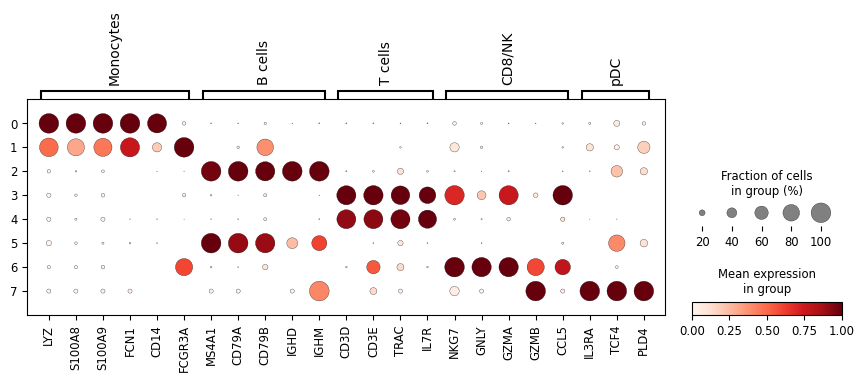

In [25]:
marker_genes = {
    "Monocytes": ["LYZ", "S100A8", "S100A9", "FCN1", "CD14", "FCGR3A"],
    "B cells": ["MS4A1", "CD79A", "CD79B", "IGHD", "IGHM"],
    "T cells": ["CD3D", "CD3E", "TRAC", "IL7R"],
    "CD8/NK": ["NKG7", "GNLY", "GZMA", "GZMB", "CCL5"],
    "pDC": ["IL3RA", "TCF4", "PLD4"],
}

sc.pl.dotplot(
    adata_marker,
    marker_genes,
    groupby="leiden",
    gene_symbols="feature_name",
    standard_scale="var",
)

Let's manually label our clusters now   

In [ ]:
cluster_cell_types = {
    "0": "Monocytes",
    "1": "Monocytes",
    "2": "B cells",
    "3": "T cells",
    "4": "T cells",
    "5": "B cells",
    "6": "CD8 cells",
    "7": "pDC",
}

adata_marker.obs["cell_type"] = adata_marker.obs["leiden"].map(cluster_cell_types) #creates a new collumn in cell metadata, remember obs is about cells

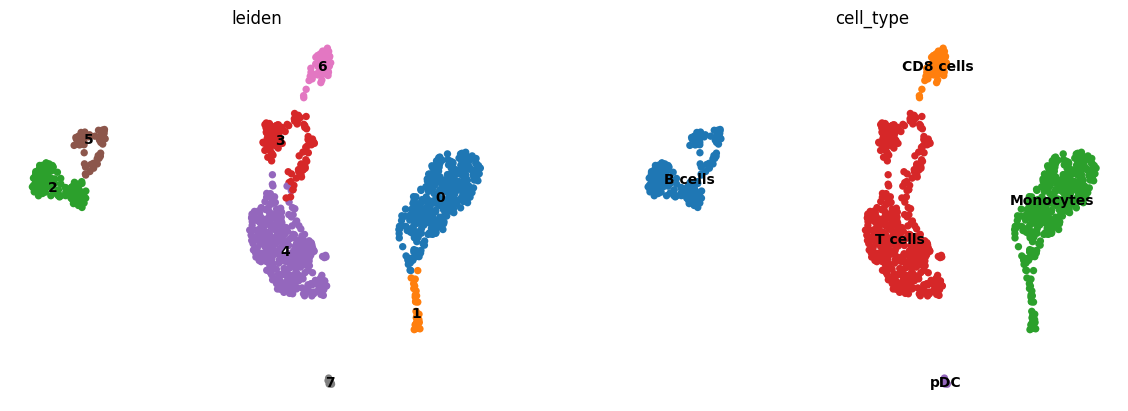

In [27]:
sc.pl.umap(
    adata_marker,
    color=["leiden", "cell_type"],
    legend_loc="on data",
    frameon=False,
)

Now we need to observe whether those genes match what we have already said

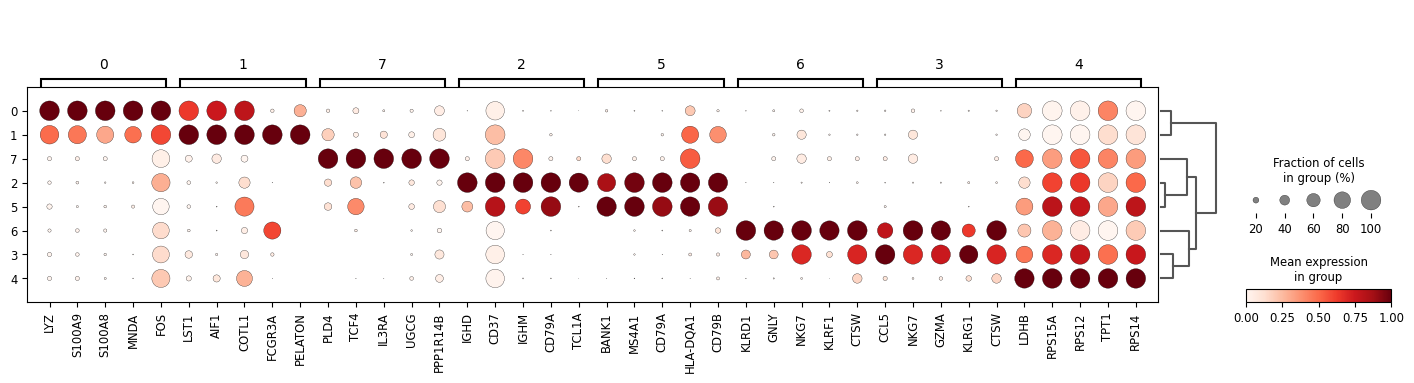

In [29]:
sc.tl.rank_genes_groups(
    adata_marker,
    groupby="leiden",
    method="wilcoxon",
    key_added="rank_genes_leiden",
)

sc.pl.rank_genes_groups_dotplot(
    adata_marker,
    groupby="leiden",
    key="rank_genes_leiden",
    standard_scale="var",
    n_genes=5,
    gene_symbols="feature_name",
)

In [ ]:
sc.get.rank_genes_groups_df(
    adata_marker,
    group="0",
    key="rank_genes_leiden",
    gene_symbols="feature_name",
).head(5)



,names,scores,logfoldchanges,pvals,pvals_adj,feature_name
0,LYZ,25.827251,9.208081,4.383418e-147,5.077630e-143,LYZ
1,S100A9,25.795658,9.617239,9.919742e-147,5.077630e-143,S100A9
2,S100A8,25.795004,9.951598,1.008868e-146,5.077630e-143,S100A8
3,MNDA,25.684536,7.443049,1.740136e-145,6.568578e-142,MNDA
4,FOS,25.584307,3.512049,2.280889e-144,6.887828e-141,FOS
